# Construct a Gaussian Mixture posterior with PCA-GMM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

/home/donglaiyang/Documents/Georgia-Tech/Research/calibrated-prior/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


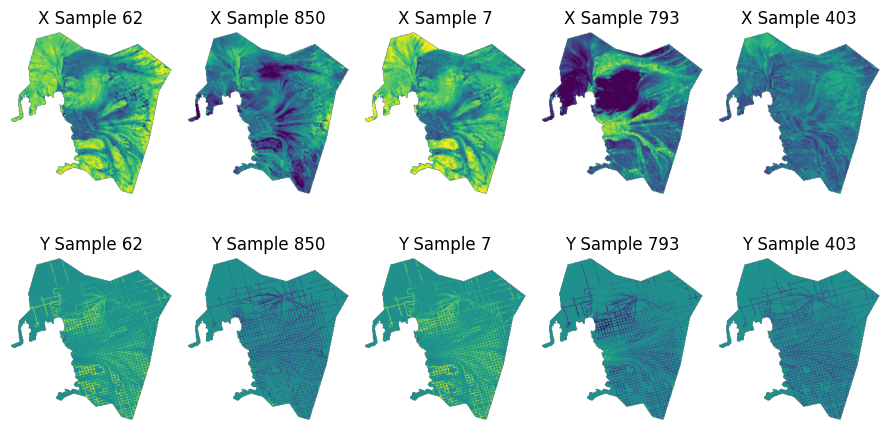

In [3]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

In [ ]:
# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=30, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=None, Y_validation=None,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)

AttributeError: 'model' object has no attribute 'find_reduction_model_pca'

In [12]:
Eb_standardized_test.shape

(256, 256, 1, 105)